In [2]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt 
import numpy as np 
from sklearn.model_selection import cross_val_score

In [7]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=42)

In [4]:
X.shape

(100, 1)

In [5]:
y.shape

(100,)

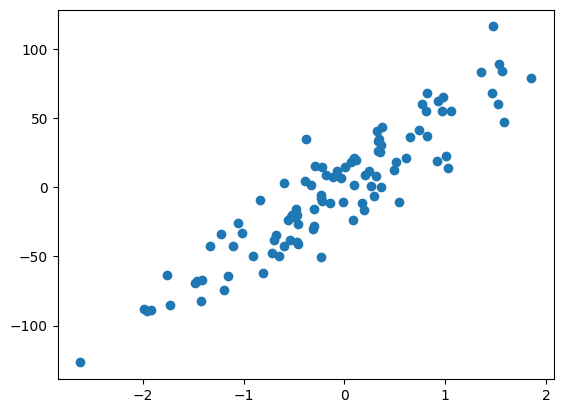

In [8]:
plt.scatter(X, y)

In [9]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [10]:
from sklearn.linear_model import LinearRegression

In [12]:
lr = LinearRegression()

In [13]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
print(lr.coef_)
print(lr.intercept_)

[46.56592693]
2.2713664531535653


In [15]:
y_pred = lr.predict(X_test)

In [16]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.878164919219213

In [17]:
class GDRegressor: 
    
    def __init__(self, learning_rate, epochs): 
        self.m = 100 
        self.b = 100 
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self, X, y): 
        
        # First we have run loop for epochs 
        for i in range(self.epochs):
            
            # Calculate slope for bias and intercept. 
            loss_slop_b = -2 * np.sum(y - self.m * X.ravel() - self.b)
            loss_slop_m = -2 * np.sum((y - self.m * X.ravel() - self.b)*X.ravel())
            
            # Update the m and b 
            self.b = self.b - (self.lr * loss_slop_b)
            self.m = self.m - (self.lr * loss_slop_m)
            
        print(self.b, self.m)
        
    def predict(self, X): 
        return self.m * X + self.b

In [18]:
gd = GDRegressor(0.001,50)

In [19]:
gd.fit(X_train,y_train)

2.3190402125055454 46.64983224863524


In [20]:
y_pred = gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.8783498961152425